
## Job Recommender System 

In [42]:
import pandas as pd
import numpy as np
import polars as pl
import warnings
warnings.filterwarnings('ignore')



### Loading Jobs and Skills Datasets

In [43]:
#Using Polars to load the datasets for better performance and memory efficiency

print("Loading datasets...")
job_postings = pl.read_csv("./data/linkedin_job_postings.csv")
job_skills    = pl.read_csv("./data/job_skills.csv")


print(f"job_postings : {job_postings.shape}")
print("\nJob Postings Dataset Columns and dtypes (df):")
for c, t in zip(job_postings.columns, job_postings.dtypes):
    print(f"  {c} : {t} : {job_postings[c].is_null().sum()}")


print(f"\n\njob_skills   : {job_skills.shape}")
print("\nJob Skills Dataset Columns and dtypes (df):")
for c, t in zip(job_skills.columns, job_skills.dtypes):
    print(f"  {c} : {t} : {job_skills[c].is_null().sum()}")



Loading datasets...
job_postings : (1348454, 14)

Job Postings Dataset Columns and dtypes (df):
  job_link : String : 0
  last_processed_time : String : 0
  got_summary : String : 0
  got_ner : String : 0
  is_being_worked : String : 0
  job_title : String : 0
  company : String : 0
  job_location : String : 0
  first_seen : String : 0
  search_city : String : 0
  search_country : String : 0
  search_position : String : 0
  job_level : String : 0
  job_type : String : 0


job_skills   : (1296381, 2)

Job Skills Dataset Columns and dtypes (df):
  job_link : String : 0
  job_skills : String : 2007


In [44]:
# Join the Jobs and Skills datasets
jobs = job_postings.join(job_skills, on='job_link', how='left')

print(f"\nCombined dataset: {jobs.shape}")
# List of column and their types and null counts
print("\nMerged DF Columns and dtypes (df):")
for c, t in zip(jobs.columns, jobs.dtypes):
    print(f"  {c} : {t} : {jobs[c].is_null().sum()}")

jobs.head(3)

del job_postings, job_skills


Combined dataset: (1348454, 15)

Merged DF Columns and dtypes (df):
  job_link : String : 0
  last_processed_time : String : 0
  got_summary : String : 0
  got_ner : String : 0
  is_being_worked : String : 0
  job_title : String : 0
  company : String : 0
  job_location : String : 0
  first_seen : String : 0
  search_city : String : 0
  search_country : String : 0
  search_position : String : 0
  job_level : String : 0
  job_type : String : 0
  job_skills : String : 54080


In the merged dataset we can see few columns with null values. These are created because of difference between the number of rows in the datasets being joined. 
So we can drop the null values.

In [45]:

print("\nMerged DF Columns and dtypes (df):")
for c, t in zip(jobs.columns, jobs.dtypes):
    print(f"  {c} : {t} : {jobs[c].is_null().sum()}")

print(f"\nCombined dataset after dropping rows with null job_skills: {jobs.shape}")


Merged DF Columns and dtypes (df):
  job_link : String : 0
  last_processed_time : String : 0
  got_summary : String : 0
  got_ner : String : 0
  is_being_worked : String : 0
  job_title : String : 0
  company : String : 0
  job_location : String : 0
  first_seen : String : 0
  search_city : String : 0
  search_country : String : 0
  search_position : String : 0
  job_level : String : 0
  job_type : String : 0
  job_skills : String : 54080

Combined dataset after dropping rows with null job_skills: (1348454, 15)


## Understanding JOBS Dataset

In [46]:
#category counts for job_type, is_being_worked, got_summary, got_ner

print("Job Type Counts:")
print(jobs['job_type'].value_counts())
print("Active Jobs Counts:")
print(jobs['is_being_worked'].value_counts())
print("Jobs with Summary Counts:")
print(jobs['got_summary'].value_counts())
print("Jobs with NER Counts:")
print(jobs['got_ner'].value_counts())

Job Type Counts:
shape: (3, 2)
┌──────────┬─────────┐
│ job_type ┆ count   │
│ ---      ┆ ---     │
│ str      ┆ u32     │
╞══════════╪═════════╡
│ Hybrid   ┆ 6562    │
│ Onsite   ┆ 1337633 │
│ Remote   ┆ 4259    │
└──────────┴─────────┘
Active Jobs Counts:
shape: (2, 2)
┌─────────────────┬─────────┐
│ is_being_worked ┆ count   │
│ ---             ┆ ---     │
│ str             ┆ u32     │
╞═════════════════╪═════════╡
│ f               ┆ 1346978 │
│ t               ┆ 1476    │
└─────────────────┴─────────┘
Jobs with Summary Counts:
shape: (2, 2)
┌─────────────┬─────────┐
│ got_summary ┆ count   │
│ ---         ┆ ---     │
│ str         ┆ u32     │
╞═════════════╪═════════╡
│ t           ┆ 1297877 │
│ f           ┆ 50577   │
└─────────────┴─────────┘
Jobs with NER Counts:
shape: (2, 2)
┌─────────┬─────────┐
│ got_ner ┆ count   │
│ ---     ┆ ---     │
│ str     ┆ u32     │
╞═════════╪═════════╡
│ t       ┆ 1296401 │
│ f       ┆ 52053   │
└─────────┴─────────┘


In [47]:
# Convert got_summary, got_ner, and is_being_worked columns to boolean
df = jobs.with_columns(
	(pl.col("got_summary").fill_null("f") == "t").cast(pl.Boolean).alias("got_summary"),
	(pl.col("got_ner").fill_null("f") == "t").cast(pl.Boolean).alias("got_ner"),
	(pl.col("is_being_worked").fill_null("f") == "t").cast(pl.Boolean).alias("is_being_worked")
)


In [48]:
print("Job Type Counts:")
print(jobs['job_type'].value_counts())

print("Job Level Counts:")
print(jobs['job_level'].value_counts())

print("Jobs Being Worked Counts:")
print(jobs['is_being_worked'].value_counts())

print("Jobs with Summary Counts:")
print(jobs['got_summary'].value_counts())

print("Jobs with NER Counts:")
print(jobs['got_ner'].value_counts())

Job Type Counts:
shape: (3, 2)
┌──────────┬─────────┐
│ job_type ┆ count   │
│ ---      ┆ ---     │
│ str      ┆ u32     │
╞══════════╪═════════╡
│ Remote   ┆ 4259    │
│ Hybrid   ┆ 6562    │
│ Onsite   ┆ 1337633 │
└──────────┴─────────┘
Job Level Counts:
shape: (2, 2)
┌────────────┬─────────┐
│ job_level  ┆ count   │
│ ---        ┆ ---     │
│ str        ┆ u32     │
╞════════════╪═════════╡
│ Mid senior ┆ 1204445 │
│ Associate  ┆ 144009  │
└────────────┴─────────┘
Jobs Being Worked Counts:
shape: (2, 2)
┌─────────────────┬─────────┐
│ is_being_worked ┆ count   │
│ ---             ┆ ---     │
│ str             ┆ u32     │
╞═════════════════╪═════════╡
│ f               ┆ 1346978 │
│ t               ┆ 1476    │
└─────────────────┴─────────┘
Jobs with Summary Counts:
shape: (2, 2)
┌─────────────┬─────────┐
│ got_summary ┆ count   │
│ ---         ┆ ---     │
│ str         ┆ u32     │
╞═════════════╪═════════╡
│ f           ┆ 50577   │
│ t           ┆ 1297877 │
└─────────────┴─────────┘
Jo

In [49]:
#Sampling the data from jobs dataset to reduce the size of the dataset for faster processing and model training. The sampling is done by dropping rows with null values in the 'job_skills' column and then randomly selecting a maximum of 300,000 rows from the remaining data. A random seed is set for reproducibility of the sampling process.
MAX_ROWS = 300_000
RANDOM_SEED = 42

df_noNulls = (
    jobs.drop_nulls(subset=["job_skills"])
      .select([
          "job_link",
          "job_title",
          "company",
          "job_location",
          "job_level",
          "job_skills",
          "job_type",
          "first_seen"
      ])
)

if df_noNulls.height > MAX_ROWS:
    df_sampled = df_noNulls.sample(
        n=MAX_ROWS,
        seed=RANDOM_SEED,
        shuffle=True,
    )

print(f"Jobs dataset for Recommendation Project: {df_sampled.height:,} rows")

Jobs dataset for Recommendation Project: 300,000 rows


In [50]:
# to pandas dataframe
df_sampled = df_sampled.to_pandas()
df_sampled = df_sampled.reset_index(drop=True)
df_sampled.head(3)

,job_link,job_title,company,job_location,job_level,job_skills,job_type,first_seen
0,https://uk.linkedin.com/jobs/view/consultant-c...,Consultant Clinical Neuro Psychologist,Sanctuary Personnel - Mental Health,"West Sussex, England, United Kingdom",Associate,"Neuropsychology, Clinical Psychology, BPS QICN...",Onsite,2024-01-13
1,https://uk.linkedin.com/jobs/view/warehouse-sh...,Warehouse Shift Operator,Cabot Corporation,"Cardiff, Wales, United Kingdom",Associate,"Warehouse Technician, Forklift Truck License, ...",Onsite,2024-01-13
2,https://uk.linkedin.com/jobs/view/site-manager...,Site Manager - Cables,ScottishPower,"Currie, Scotland, United Kingdom",Mid senior,"Electrical design drawings, Circuit diagrams, ...",Onsite,2024-01-16


### DATA CLEANING

In [51]:
# Align with the original labels: "Mid senior" and "Associate"
def clean_level(level):
    level = str(level).strip().lower()
    if 'associate' in level:
        return 'Associate'
    elif 'mid' in level or 'senior' in level:
        return 'Mid-Senior'
    else:
        return 'Other'

df_sampled['job_level_clean'] = df_sampled['job_level'].apply(clean_level)
df_sampled = df_sampled[df_sampled['job_level_clean'] != 'Other'].copy()

# Normalize skills: lowercase and strip whitespace
df_sampled['job_skills'] = df_sampled['job_skills'].astype(str).str.lower().str.strip()

print("Job level after cleaning:")
print(df_sampled['job_level_clean'].value_counts())
print(f"\nTotal data ready: {df_sampled.shape[0]:,} rows")

Job level after cleaning:
job_level_clean
Mid-Senior    267228
Associate      32772
Name: count, dtype: int64

Total data ready: 300,000 rows


### Exploratory Data Analysis (EDA) Visualizations

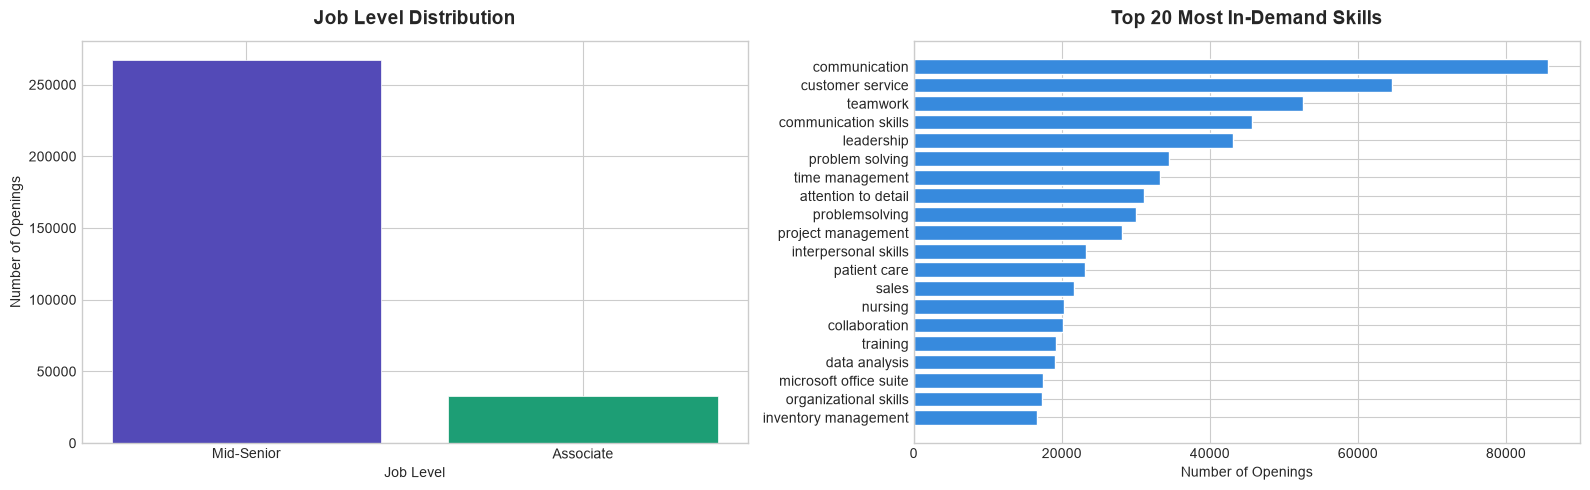

Plot saved: ./images/eda_overview.png


In [52]:
import matplotlib.pyplot as plt
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Job level distribution

colors = ['#534AB7', '#1D9E75', '#D85A30']
axes[0].bar(
    df_sampled['job_level_clean'].value_counts().index,
    df_sampled['job_level_clean'].value_counts().values,
    color=colors,
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_title('Job Level Distribution', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Job Level')
axes[0].set_ylabel('Number of Openings')


# Plot 2: Top 20 overall skills
all_skills = []
for skills_str in df_sampled['job_skills']:
    skills = [s.strip() for s in str(skills_str).split(',')]
    all_skills.extend(skills)

top_skills = pd.Series(Counter(all_skills)).nlargest(20)
axes[1].barh(top_skills.index[::-1], top_skills.values[::-1], color='#378ADD', edgecolor='white')
axes[1].set_title('Top 20 Most In-Demand Skills', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Number of Openings')

plt.tight_layout()
plt.savefig('./images/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: ./images/eda_overview.png")

## Top 10 skills

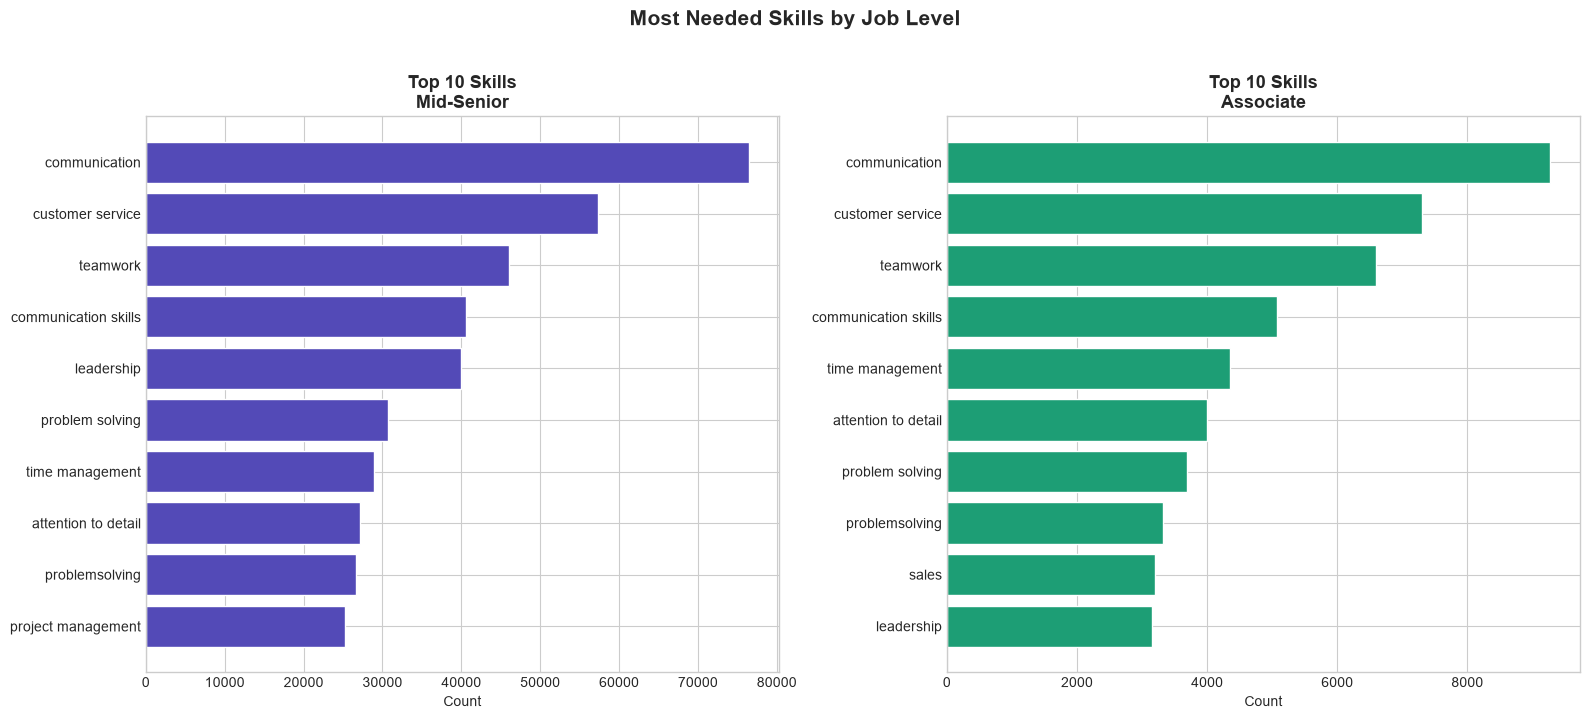

Plot saved: ./images/skills_per_level.png


In [53]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
levels = ['Mid-Senior', 'Associate']
colors_map = {'Mid-Senior': '#534AB7', 'Associate': '#1D9E75'}

for ax, level in zip(axes, levels):
    subset = df_sampled[df_sampled['job_level_clean'] == level]
    skills_list = []
    for s in subset['job_skills'].dropna():
        skills_list.extend([x.strip() for x in str(s).split(',')])
    top = pd.Series(Counter(skills_list)).nlargest(10)
    ax.barh(top.index[::-1], top.values[::-1], color=colors_map[level], edgecolor='white')
    ax.set_title(f'Top 10 Skills\n{level}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Count')

plt.suptitle('Most Needed Skills by Job Level', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./images/skills_per_level.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: ./images/skills_per_level.png")

In [54]:
print("Job Type", df_sampled['job_type'].value_counts())

Job Type job_type
Onsite    297569
Hybrid      1508
Remote       923
Name: count, dtype: int64


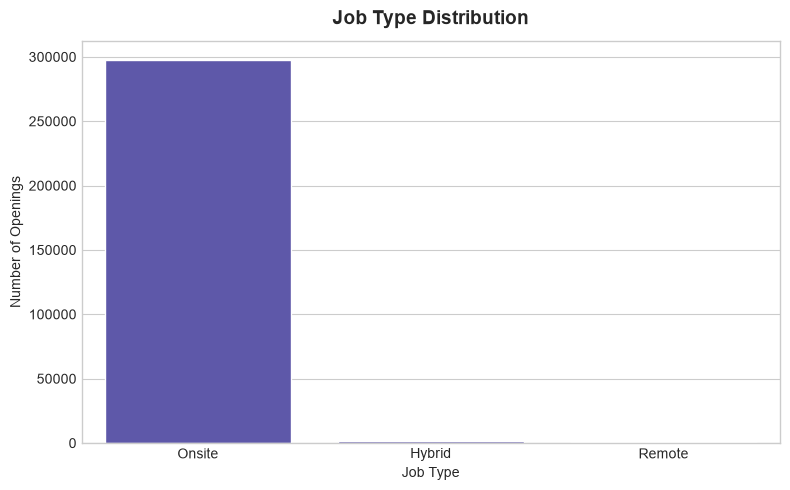

In [55]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x=df_sampled['job_type'], color='#534AB7', edgecolor='white')
plt.title('Job Type Distribution', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Job Type')
plt.ylabel('Number of Openings')
plt.tight_layout()
plt.savefig('./images/job_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
#Converting the 'first_seen' column to datetime format for further analysis and processing. 
#This ensures that the dates are in a consistent format and can be used for time-based operations, such as filtering or sorting by date.
df_sampled["first_seen"] = pd.to_datetime(df_sampled["first_seen"], utc=True, errors="coerce")

In [57]:
# Created the scripts under the scripts folder to generate users.csv based on the sampled job postings in df_sampled.
# The script 'generate_users_from_df' will create a specified number of users and save it in users.csv
# The script 'generate_interactions_from_df' will create user interactions based on the sampled job postings and save it in user_interactions.csv

from Scripts.generate_user_interactions import generate_interactions_from_df
from Scripts.generate_users import generate_users_from_df

generate_users_from_df(df_sampled, output_path="./data/users.csv")
users_df = pd.read_csv("./data/users.csv")
users_df.head()


,user_id,n_interactions,last_interaction_ts,top_skills,preferred_job_titles,most_common_location
0,user_0001,3,2024-01-14T00:00:00+00:00,"[""communication"", ""401k"", ""accredited school o...","[""Fine Dining Restaurant Operations General Ma...","Colorado Springs, CO"
1,user_0002,3,2024-01-16T00:00:00+00:00,"[""communication"", ""innovation"", ""organizationa...","[""Mergers and Acquisitions Analyst"", ""Highway/...","Hamilton, Ontario, Canada"
2,user_0003,7,2024-01-16T00:00:00+00:00,"[""communication skills"", ""customer service ski...","[""Family Practice Physician"", ""Customer Servic...","Pasadena, TX"
3,user_0004,5,2024-01-16T00:00:00+00:00,"[""employee assistance program"", ""life insuranc...","[""Senior Lead Engineer- Generative AI Engineer...","Brookhaven, NY"
4,user_0005,8,2024-01-15T00:00:00+00:00,"[""iam"", ""testing"", ""aws"", ""building codes"", ""c...","[""Manager Construction, Maintenance and Emerge...","Beaumont, Alberta, Canada"


In [58]:
generate_interactions_from_df(df_sampled, output_path="./data/user_interactions.csv")
user_interactions_df = pd.read_csv("./data/user_interactions.csv")
user_interactions_df.head()

,user_id,job_link,job_title,job_location,first_seen
0,user_0001,https://ca.linkedin.com/jobs/view/fine-dining-...,Fine Dining Restaurant Operations General Mana...,"Kahnawake, Quebec, Canada",2024-01-13T00:00:00+00:00
1,user_0001,https://uk.linkedin.com/jobs/view/gastrointest...,Gastrointestinal Nurse Practitioner/Non-Medica...,"Lymington, England, United Kingdom",2024-01-13T00:00:00+00:00
2,user_0001,https://www.linkedin.com/jobs/view/registered-...,Registered Nurse Infusion,"Colorado Springs, CO",2024-01-14T00:00:00+00:00
3,user_0002,https://www.linkedin.com/jobs/view/mergers-and...,Mergers and Acquisitions Analyst,"Irving, TX",2024-01-13T00:00:00+00:00
4,user_0002,https://www.linkedin.com/jobs/view/highway-roa...,Highway/Roadway Engineer*,"Nashville, TN",2024-01-16T00:00:00+00:00


### Feature Engineering On Jobs Dataset using TF-IDF

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import scipy.sparse as sp

# Additional stopwords specific to the job skills dataset
custom_stopwords = [
    'and', 'or', 'to', 'of', 'in', 'on', 'for', 'with', 'the', 'a', 'an',
    'skills', 'skill', 'ability', 'abilities', 'knowledge', 'experience',
    'work', 'working', 'required', 'preferred', 'proficiency', 'strong',
    'excellent', 'good', 'plus', 'including', 'etc', 'using', 'use',
    'tools', 'tool', 'systems', 'system', 'software', 'application',
    'applications', 'various', 'related', 'relevant'
]


def clean_skills_text(text):
    text = str(text).lower()
    
    # Replace common separators with spaces
    text = text.replace(',', ' ')
    text = text.replace('/', ' ')
    text = text.replace('|', ' ')
    text = text.replace(';', ' ')
    text = text.replace('&', ' and ')
    
    # Remove characters other than letters, numbers, +, #, and dot
    # So skills like c++, c#, and node.js are not damaged
    text = re.sub(r'[^a-z0-9+#.\s]', ' ', text)
    
    # Clean up extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


df_sampled['job_skills_clean'] = df_sampled['job_skills'].apply(clean_skills_text)

print("Example before and after preprocessing:")
display(df_sampled[['job_skills', 'job_skills_clean']].head())


print("\nTF-IDF processing for the Jobs Dataset...")

tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    stop_words=custom_stopwords,
    min_df=5,
    max_df=0.85,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z0-9+#.]+\b'
)

job_skill_matrix = tfidf.fit_transform(df_sampled['job_skills_clean'])

def normalize_vector(vec):
    if sp.issparse(vec):
        arr = vec.toarray().ravel()
    else:
        arr = np.asarray(vec).ravel()
    norm = np.linalg.norm(arr)
    return arr / norm if norm > 0 else arr


job_skill_vectors = np.array([normalize_vector(job_skill_matrix[i]) for i in range(job_skill_matrix.shape[0])])

print(f"Total Jobs data : {df_sampled.shape[0]:,} job postings")
print(f"Number of TF-IDF features : {job_skill_vectors.shape[1]} features")

Example before and after preprocessing:


,job_skills,job_skills_clean
0,"neuropsychology, clinical psychology, bps qicn...",neuropsychology clinical psychology bps qicn q...
1,"warehouse technician, forklift truck license, ...",warehouse technician forklift truck license dr...
2,"electrical design drawings, circuit diagrams, ...",electrical design drawings circuit diagrams wi...
3,"civil engineering, project management, design ...",civil engineering project management design ca...
4,"customer service, sales, communication, teamwo...",customer service sales communication teamwork ...



TF-IDF processing for the Jobs Dataset...
Total Jobs data : 300,000 job postings
Number of TF-IDF features : 500 features


## Top Features For JOBS DATASET Using TF-IDF

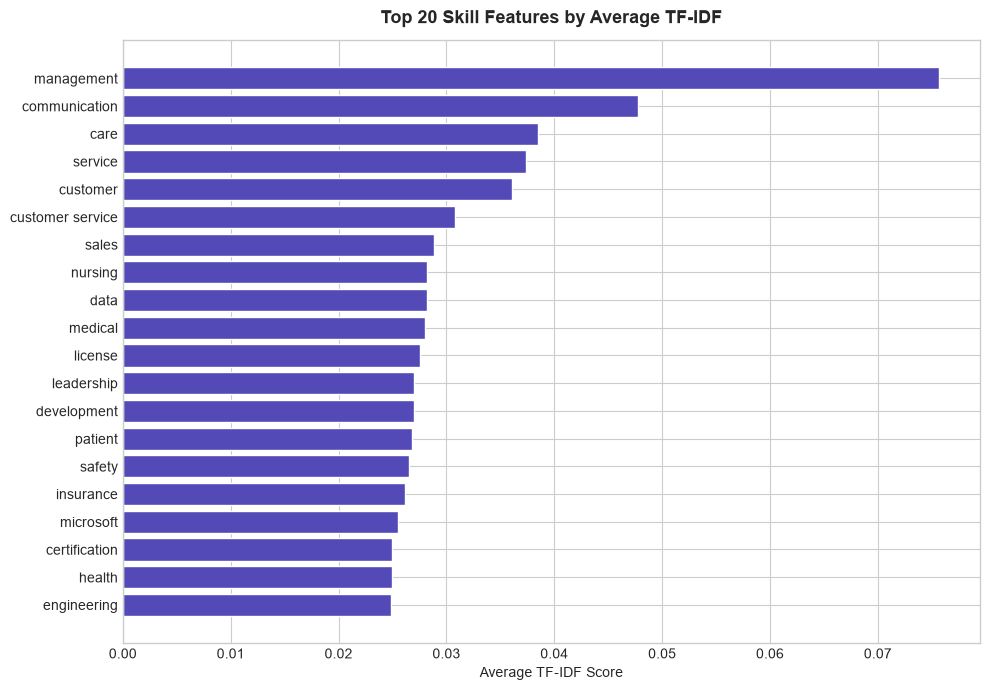

In [60]:
feature_names = tfidf.get_feature_names_out()

# Calculate the average TF-IDF weight for each feature
mean_tfidf_scores = np.asarray(job_skill_vectors.mean(axis=0)).flatten()

top_idx = np.argsort(mean_tfidf_scores)[::-1][:20]

top_feat = [feature_names[i] for i in top_idx]
top_scores = [mean_tfidf_scores[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(top_feat[::-1], top_scores[::-1], color='#534AB7', edgecolor='white')
ax.set_title('Top 20 Skill Features by Average TF-IDF',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Average TF-IDF Score')

plt.tight_layout()
plt.savefig('./images/top_tfidf_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
# Features for users and interactions

import ast
from sklearn.preprocessing import normalize
import scipy.sparse as sp


# Helper to convert the JSON-like list columns into Python lists
def parse_json_list(value):
    if pd.isna(value) or value == "":
        return []
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass
    return [t.strip() for t in str(value).split(",") if t.strip()]

users_df["top_skills_list"] = users_df["top_skills"].apply(parse_json_list)
users_df["preferred_titles_list"] = users_df["preferred_job_titles"].apply(parse_json_list)

# Turn the user profile lists into query-style text
users_df["top_skills_text"] = users_df["top_skills_list"].apply(
    lambda skills: " ".join([s.lower() for s in skills])
)
users_df["preferred_titles_text"] = users_df["preferred_titles_list"].apply(
    lambda titles: " ".join([t.lower() for t in titles])
)

users_df["top_skills_text"] = users_df["top_skills_text"].apply(clean_skills_text)
# Reuse the existing TF-IDF trained on job skills for user skill profile vectors
user_skill_matrix = tfidf.transform(users_df["top_skills_text"].fillna(""))

def normalize_vector(vec):
    if sp.issparse(vec):
        arr = vec.toarray().ravel()
    else:
        arr = np.asarray(vec).ravel()
    norm = np.linalg.norm(arr)
    return arr / norm if norm > 0 else arr

user_skill_vectors = {uid: normalize_vector(user_skill_matrix[i]) for i, uid in enumerate(users_df["user_id"])}

users_df["user_skill_vector"] = users_df["user_id"].map(user_skill_vectors)

# # Optional: create a separate title TF-IDF representation for preferred titles
# title_vectorizer = TfidfVectorizer(
#     max_features=200,
#     ngram_range=(1, 2),
#     stop_words="english",
#     token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9+#.]+\b",
# )
# user_title_vectors = title_vectorizer.fit_transform(users_df["preferred_titles_text"].fillna(""))

# Parse the location into structured fields
def split_location(location):
    parts = [p.strip() for p in str(location).split(",") if p.strip()]
    return pd.Series({
        "user_city": parts[0] if len(parts) >= 1 else "",
        "user_state": parts[1] if len(parts) >= 2 else "",
        "user_country": parts[-1] if len(parts) >= 1 else "",
    })

location_parts = users_df["most_common_location"].fillna("").apply(split_location)
users_df = pd.concat([users_df, location_parts], axis=1)

# Add profile statistics
users_df["n_interactions"] = users_df["n_interactions"].astype(int)
users_df["last_interaction_ts"] = pd.to_datetime(users_df["last_interaction_ts"], errors="coerce")
# ensure timestamps are timezone-aware (UTC) before subtracting
users_df["last_interaction_ts"] = pd.to_datetime(users_df["last_interaction_ts"], utc=True)
users_df["days_since_last_interaction"] = (
    pd.Timestamp.now(tz="UTC").normalize() - users_df["last_interaction_ts"]
).dt.days
users_df["skill_diversity"] = users_df["top_skills_list"].apply(lambda skills: len(set(skills)))
users_df["title_diversity"] = users_df["preferred_titles_list"].apply(lambda titles: len(set(titles)))
users_df["preferred_title_1"] = users_df["preferred_titles_list"].apply(lambda titles: titles[0] if titles else "")
users_df["preferred_titles_count"] = users_df["preferred_titles_list"].apply(len)



In [62]:
users_df.head()

,user_id,n_interactions,last_interaction_ts,top_skills,preferred_job_titles,most_common_location,top_skills_list,preferred_titles_list,top_skills_text,preferred_titles_text,user_skill_vector,user_city,user_state,user_country,days_since_last_interaction,skill_diversity,title_diversity,preferred_title_1,preferred_titles_count
0,user_0001,3,2024-01-14 00:00:00+00:00,"[""communication"", ""401k"", ""accredited school o...","[""Fine Dining Restaurant Operations General Ma...","Colorado Springs, CO","[communication, 401k, accredited school of nur...",[Fine Dining Restaurant Operations General Man...,communication 401k accredited school of nursin...,fine dining restaurant operations general mana...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Colorado Springs,CO,CO,931,12,3,Fine Dining Restaurant Operations General Mana...,3
1,user_0002,3,2024-01-16 00:00:00+00:00,"[""communication"", ""innovation"", ""organizationa...","[""Mergers and Acquisitions Analyst"", ""Highway/...","Hamilton, Ontario, Canada","[communication, innovation, organizational ski...","[Mergers and Acquisitions Analyst, Highway/Roa...",communication innovation organizational skills...,mergers and acquisitions analyst highway/roadw...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Hamilton,Ontario,Canada,929,12,3,Mergers and Acquisitions Analyst,3
2,user_0003,7,2024-01-16 00:00:00+00:00,"[""communication skills"", ""customer service ski...","[""Family Practice Physician"", ""Customer Servic...","Pasadena, TX","[communication skills, customer service skills...","[Family Practice Physician, Customer Service A...",communication skills customer service skills m...,family practice physician customer service age...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Pasadena,TX,TX,929,12,7,Family Practice Physician,7
3,user_0004,5,2024-01-16 00:00:00+00:00,"[""employee assistance program"", ""life insuranc...","[""Senior Lead Engineer- Generative AI Engineer...","Brookhaven, NY","[employee assistance program, life insurance, ...",[Senior Lead Engineer- Generative AI Engineeri...,employee assistance program life insurance pro...,senior lead engineer- generative ai engineerin...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Brookhaven,NY,NY,929,12,5,Senior Lead Engineer- Generative AI Engineerin...,5
4,user_0005,8,2024-01-15 00:00:00+00:00,"[""iam"", ""testing"", ""aws"", ""building codes"", ""c...","[""Manager Construction, Maintenance and Emerge...","Beaumont, Alberta, Canada","[iam, testing, aws, building codes, change con...","[Manager Construction, Maintenance and Emergen...",iam testing aws building codes change control ...,"manager construction, maintenance and emergenc...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Beaumont,Alberta,Canada,930,12,8,"Manager Construction, Maintenance and Emergencies",8


In [63]:
# Build averaged job-vector profiles from the user interactions

df_sampled["job_link"] = df_sampled["job_link"].astype(str).str.strip()

user_interactions_df["job_link"] = user_interactions_df["job_link"].astype(str).str.strip()
interaction_skills = user_interactions_df.merge(df_sampled[["job_link", "job_skills"]], on="job_link", how="left")

interaction_skills["job_skills"] = interaction_skills["job_skills"].fillna("").apply(clean_skills_text)

job_skill_interaction_matrix = tfidf.transform(interaction_skills["job_skills"].fillna(""))

user_profile_vectors = {}
for user_id, group in interaction_skills.groupby("user_id").indices.items():
    subset = job_skill_interaction_matrix[group]
    if subset.shape[0] == 0:
        user_profile_vectors[user_id] = np.zeros((job_skill_interaction_matrix.shape[1],), dtype=float)
        continue
    avg_vec = subset.mean(axis=0)
    if sp.issparse(avg_vec):
        avg_vec = normalize(avg_vec)
        avg_vec = avg_vec.toarray().ravel()
    else:
        avg_vec = np.asarray(avg_vec).ravel()
        norm = np.linalg.norm(avg_vec)
        if norm > 0:
            avg_vec = avg_vec / norm
    user_profile_vectors[user_id] = avg_vec

users_df["profile_job_vector"] = users_df["user_id"].map(user_profile_vectors)

# Keep the transformed features in a separate feature frame
user_features = users_df[[
    "user_id",
    "n_interactions",
    "last_interaction_ts",
    "days_since_last_interaction",
    "skill_diversity",
    "title_diversity",
    "preferred_title_1",
    "preferred_titles_count",
    "user_city",
    "user_state",
    "user_country",
    "top_skills_text",
    "preferred_titles_text",
    "user_skill_vector", #it contains the TF-IDF vector for the user's top skills
    "profile_job_vector", #it contains the averaged job skill vector for the user based on their interactions
]]

print("User feature frame shape:", user_features.shape)
print(user_features.head(3).T)

User feature frame shape: (1000, 15)
                                                                             0  \
user_id                                                              user_0001   
n_interactions                                                               3   
last_interaction_ts                                  2024-01-14 00:00:00+00:00   
days_since_last_interaction                                                931   
skill_diversity                                                             12   
title_diversity                                                              3   
preferred_title_1            Fine Dining Restaurant Operations General Mana...   
preferred_titles_count                                                       3   
user_city                                                     Colorado Springs   
user_state                                                                  CO   
user_country                                                 

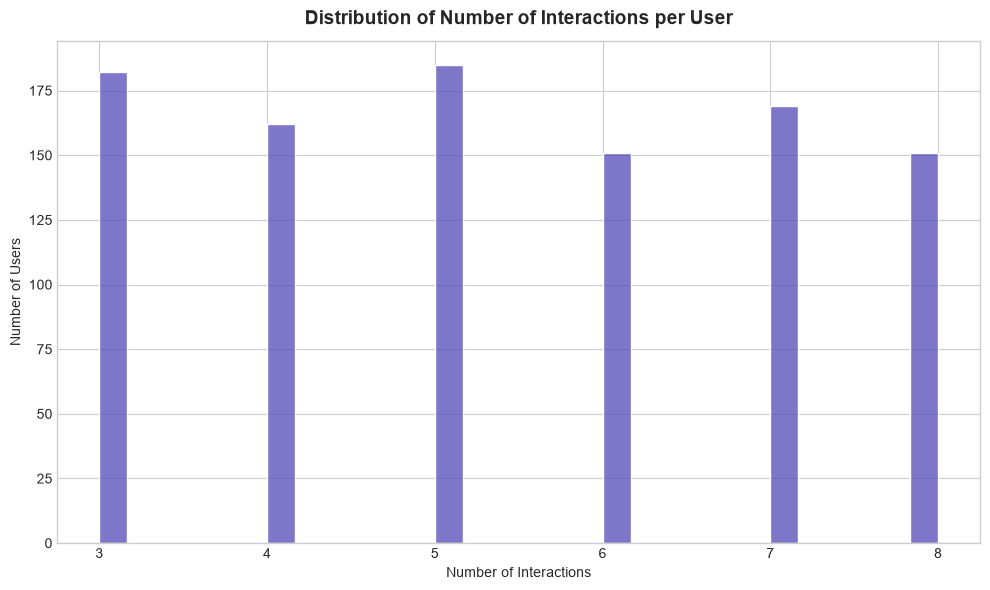

Plot saved: ./images/user_interactions_distribution.png


In [64]:
# User Feature Engineering

#plot the distribution of the number of interactions per user
plt.figure(figsize=(10, 6))
sns.histplot(users_df['n_interactions'], bins=30, kde=False, color='#534AB7', edgecolor='white')
plt.title('Distribution of Number of Interactions per User', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig('./images/user_interactions_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: ./images/user_interactions_distribution.png")    

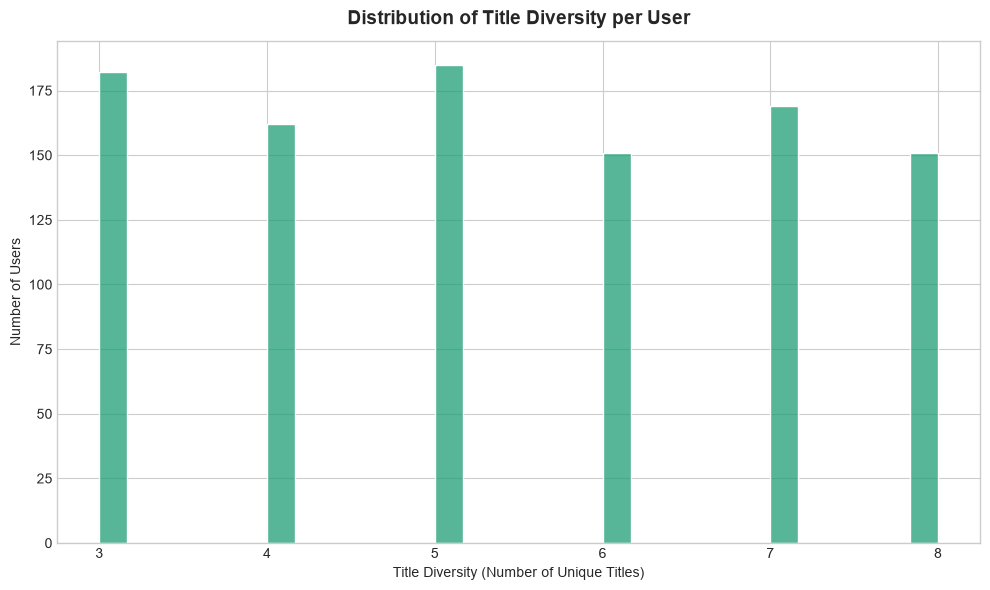

Plot saved: ./images/user_title_diversity_distribution.png


In [65]:
#plot the most meaningful features for the users based on the number of interactions, skill diversity, and title diversity. The plots will help visualize the distribution of these features across the user base and identify any patterns or trends that may be useful for recommendation system development. 
plt.figure(figsize=(10, 6))
sns.histplot(users_df['title_diversity'], bins=30, kde=False, color='#1D9E75', edgecolor='white')
plt.title('Distribution of Title Diversity per User', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Title Diversity (Number of Unique Titles)')
plt.ylabel('Number of Users')
plt.tight_layout()      
plt.savefig('./images/user_title_diversity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: ./images/user_title_diversity_distribution.png")

### Use the interaction data for creating the vectorized data for the recommandation system

In [66]:
import ast
import random
import scipy.sparse as sp

# Load user interaction data

user_interactions_df["job_link"] = user_interactions_df["job_link"].astype(str).str.strip()
user_interactions_df["user_id"] = user_interactions_df["user_id"].astype(str).str.strip()
user_interactions_df["first_seen"] = pd.to_datetime(user_interactions_df["first_seen"], utc=True, errors="coerce")


# Leave-last-out temporal split
def leave_last_out(interactions_df):
    interactions_df = interactions_df.sort_values(["user_id", "first_seen"])
    train_rows, val_rows, test_rows = [], [], []
    for user_id, group in interactions_df.groupby("user_id"):
        group = group.reset_index(drop=True)
        if len(group) <= 2:
            train_rows.extend(group.index[:-1].tolist())
            test_rows.extend(group.index[-1:].tolist())
        else:
            train_rows.extend(group.index[:-2].tolist())
            val_rows.append(group.index[-2])
            test_rows.append(group.index[-1])
    train = interactions_df.loc[train_rows].reset_index(drop=True)
    val = interactions_df.loc[val_rows].reset_index(drop=True)
    test = interactions_df.loc[test_rows].reset_index(drop=True)
    return train, val, test

train_interactions, val_interactions, test_interactions = leave_last_out(user_interactions_df)
print("Train / Val / Test:", train_interactions.shape, val_interactions.shape, test_interactions.shape)


Train / Val / Test: (3416, 5) (1000, 5) (1000, 5)


In [67]:
train_interactions.head(3)

,user_id,job_link,job_title,job_location,first_seen
0,user_0001,https://ca.linkedin.com/jobs/view/fine-dining-...,Fine Dining Restaurant Operations General Mana...,"Kahnawake, Quebec, Canada",2024-01-13 00:00:00+00:00
1,user_0001,https://ca.linkedin.com/jobs/view/fine-dining-...,Fine Dining Restaurant Operations General Mana...,"Kahnawake, Quebec, Canada",2024-01-13 00:00:00+00:00
2,user_0001,https://ca.linkedin.com/jobs/view/fine-dining-...,Fine Dining Restaurant Operations General Mana...,"Kahnawake, Quebec, Canada",2024-01-13 00:00:00+00:00


In [68]:
# Job popularity and average level per user
job_popularity = train_interactions["job_link"].value_counts().to_dict()
train_levels = train_interactions.merge(
    df_sampled[["job_link", "job_level_clean"]], on="job_link", how="left"
)
user_level_mode = train_levels.groupby("user_id")["job_level_clean"].agg(
    lambda x: x.mode().iloc[0] if len(x.dropna()) > 0 else ""
).to_dict()

# Candidate feature builder
def jaccard_overlap(list_a, list_b):
    set_a, set_b = set([str(x).strip().lower() for x in list_a if x]) , set([str(x).strip().lower() for x in list_b if x])
    if not set_a or not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)

def location_match(user_row, job_loc):
    job_parts = [p.strip() for p in str(job_loc).split(",") if p.strip()]
    if not job_parts:
        return 0
    job_city = job_parts[0]
    job_state = job_parts[1] if len(job_parts) >= 2 else ""
    job_country = job_parts[-1]

    user_city = str(user_row.get("user_city", "") or "").strip()
    user_state = str(user_row.get("user_state", "") or "").strip()
    user_country = str(user_row.get("user_country", "") or "").strip()

    if user_country.lower() == job_country.lower() and user_country:
        return 1
    if user_state.lower() == job_state.lower() and user_state:
        return 1
    if user_city.lower() == job_city.lower() and user_city:
        return 1
    return 0


def title_match(user_row, job_title):
    title_lower = str(job_title).lower()
    preferred_titles = user_row.get("preferred_titles_list", [])
    if isinstance(preferred_titles, (str, bytes)):
        preferred_titles = [preferred_titles]
    for preferred in preferred_titles or []:
        if preferred and str(preferred).lower() in title_lower:
            return 1
    return 0
def build_pair_features(user_id, job_link, label):
    row = {"user_id": user_id, "job_link": job_link, "label": label}
    user_row = users_df.loc[users_df["user_id"] == user_id].iloc[0]
    if job_link not in row_index:
        return None
    job_row = df_sampled.iloc[row_index[job_link]]
    job_vec = np.atleast_2d(job_skill_vectors[row_index[job_link]])
    user_skill_vec = np.atleast_2d(
        user_skill_vectors.get(user_id, np.zeros(job_skill_vectors.shape[1], dtype=float))
    )
    profile_vec = np.atleast_2d(
        user_profile_vectors.get(user_id, np.zeros(job_skill_vectors.shape[1], dtype=float))
    )

    row["skill_similarity"] = float(cosine_similarity(
        user_skill_vec, job_vec
    )[0, 0]) if np.any(user_skill_vec) else 0.0

    row["profile_similarity"] = float(cosine_similarity(
        profile_vec, job_vec
    )[0, 0]) if np.any(profile_vec) else 0.0

    job_skill_list = [s.strip() for s in str(job_row["job_skills"]).split(",") if s.strip()]
    row["skill_overlap"] = jaccard_overlap(user_row["top_skills_list"], job_skill_list)
    row["location_match"] = location_match(user_row, job_row["job_location"])
    row["title_match"] = title_match(user_row, job_row["job_title"])
    row["job_level_match"] = int(
        str(job_row["job_level_clean"]).strip().lower()
        == str(user_level_mode.get(user_id, "")).strip().lower()
    )
    row["job_popularity"] = job_popularity.get(job_link, 0)
    row["job_age_days"] = (
        pd.Timestamp.now(tz="UTC") - job_row["first_seen"]
    ).days if pd.notna(job_row["first_seen"]) else np.nan
    row["n_interactions"] = user_row["n_interactions"]
    row["days_since_last_interaction"] = user_row["days_since_last_interaction"]
    row["skill_diversity"] = user_row["skill_diversity"]
    row["title_diversity"] = user_row["title_diversity"]
    row["preferred_titles_count"] = user_row["preferred_titles_list"].__len__()
    return row

# Build negative samples for training and evaluation
all_job_links = set(df_sampled["job_link"])
negatives_per_positive = 10
random.seed(42)

def sample_negatives_for_user(user_id, positives, n_samples):
    negative_pool = list(all_job_links - set(positives))
    if not negative_pool:
        return []
    return random.sample(negative_pool, min(n_samples, len(negative_pool)))

def build_candidates(interactions_df, include_negative=True):
    candidate_rows = []
    for user_id, group in interactions_df.groupby("user_id"):
        positives = group["job_link"].tolist()
        for job_link in positives:
            row = build_pair_features(user_id, job_link, 1)
            if row:
                candidate_rows.append(row)
        if include_negative:
            negs = sample_negatives_for_user(user_id, positives, len(positives) * negatives_per_positive)
            for job_link in negs:
                row = build_pair_features(user_id, job_link, 0)
                if row:
                    candidate_rows.append(row)
    return pd.DataFrame(candidate_rows)

# ensure the job_link lookup map is defined before building candidate pairs
# This is a labeled dataset of user-job candidate pairs, not a prediction result yet.
row_index = {link: idx for idx, link in enumerate(df_sampled["job_link"]) if pd.notna(link)}
train_pairs = build_candidates(train_interactions, include_negative=True)
val_pairs = build_candidates(val_interactions, include_negative=True)
test_pairs = build_candidates(test_interactions, include_negative=True)

print("Train pairs:", train_pairs.shape)
print("Val pairs:", val_pairs.shape)
print("Test pairs:", test_pairs.shape)
print(train_pairs.head(5).T)


Train pairs: (37576, 16)
Val pairs: (11000, 16)
Test pairs: (11000, 16)
                                                                             0  \
user_id                                                              user_0001   
job_link                     https://ca.linkedin.com/jobs/view/fine-dining-...   
label                                                                        1   
skill_similarity                                                      0.111421   
profile_similarity                                                    0.564252   
skill_overlap                                                             0.12   
location_match                                                               0   
title_match                                                                  1   
job_level_match                                                              1   
job_popularity                                                            1000   
job_age_days              

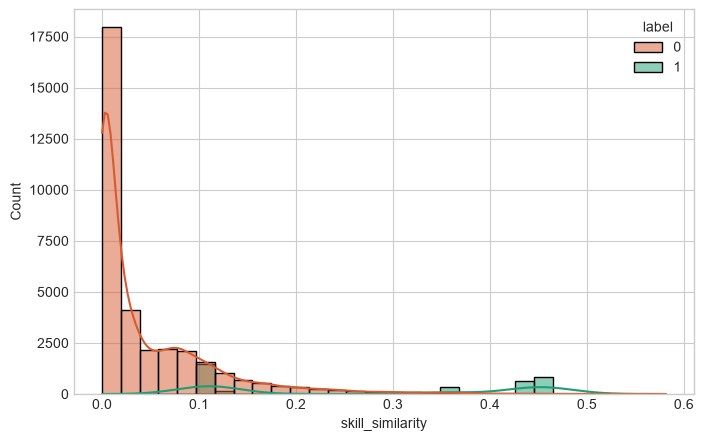

In [69]:
plt.figure(figsize=(8, 5))
sns.histplot(data=train_pairs, x="skill_similarity", hue="label", bins=30, kde=True, palette={0: "#D85A30", 1: "#1D9E75"})
plt.show()

In [70]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

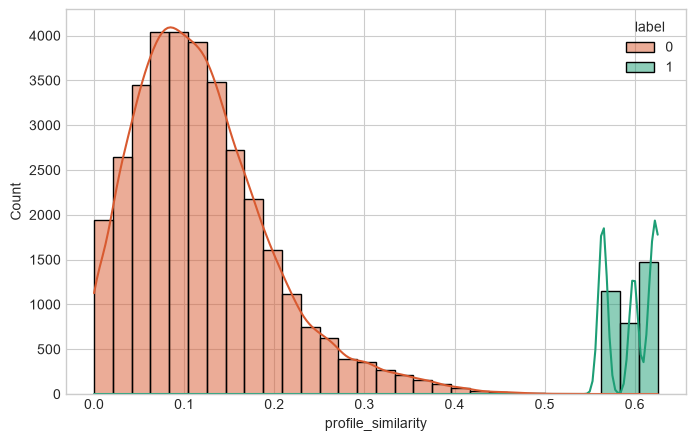

In [71]:
plt.figure(figsize=(8, 5))
sns.histplot(data=train_pairs, x="profile_similarity", hue="label", bins=30, kde=True, palette={0: "#D85A30", 1: "#1D9E75"})
plt.show()

### Train the baseline Classification model

In [72]:
# Now we need to use the labelled dataset to train a classification model.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

feature_cols = [
    "skill_similarity",
    "profile_similarity",
    "skill_overlap",
    "location_match",
    "title_match",
    "job_level_match",
    "job_popularity",
    "job_age_days",
    "n_interactions",
    "days_since_last_interaction",
    "skill_diversity",
    "title_diversity",
    "preferred_titles_count",
]

X_train = train_pairs[feature_cols].fillna(0)
y_train = train_pairs["label"].astype(int)

X_val = val_pairs[feature_cols].fillna(0)
y_val = val_pairs["label"].astype(int)

X_test = test_pairs[feature_cols].fillna(0)
y_test = test_pairs["label"].astype(int)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train, y_train)

for name, X, y in [("val", X_val, y_val), ("test", X_test, y_test)]:
    y_pred = clf.predict(X)
    y_prob = clf.predict_proba(X)[:, 1]
    print(name, "accuracy:", accuracy_score(y, y_pred))
    print(name, "AUC:", roc_auc_score(y, y_prob))
    print(classification_report(y, y_pred, digits=4))



val accuracy: 0.9862727272727273
val AUC: 0.9149115
              precision    recall  f1-score   support

           0     0.9851    1.0000    0.9925     10000
           1     1.0000    0.8490    0.9183      1000

    accuracy                         0.9863     11000
   macro avg     0.9926    0.9245    0.9554     11000
weighted avg     0.9865    0.9863    0.9858     11000

test accuracy: 0.9708181818181818
test AUC: 0.76478205
              precision    recall  f1-score   support

           0     0.9690    0.9999    0.9842     10000
           1     0.9985    0.6800    0.8090      1000

    accuracy                         0.9708     11000
   macro avg     0.9838    0.8399    0.8966     11000
weighted avg     0.9717    0.9708    0.9683     11000



### Use other classification Models like:

#### --> DecisionTreeClassifier
#### --> RandomForestClassifier
#### --> XGBoost

In [73]:
# decision tree classifier 
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
dt_clf.fit(X_train, y_train)

for name, X, y in [("val", X_val, y_val), ("test", X_test, y_test)]:
    y_pred = dt_clf.predict(X)
    y_prob = dt_clf.predict_proba(X)[:, 1]
    print(name, "accuracy:", accuracy_score(y, y_pred))
    print(name, "AUC:", roc_auc_score(y, y_prob))
    print(classification_report(y, y_pred, digits=4))

val accuracy: 0.9862727272727273
val AUC: 0.9245
              precision    recall  f1-score   support

           0     0.9851    1.0000    0.9925     10000
           1     1.0000    0.8490    0.9183      1000

    accuracy                         0.9863     11000
   macro avg     0.9926    0.9245    0.9554     11000
weighted avg     0.9865    0.9863    0.9858     11000

test accuracy: 0.9708181818181818
test AUC: 0.8399500000000001
              precision    recall  f1-score   support

           0     0.9690    0.9999    0.9842     10000
           1     0.9985    0.6800    0.8090      1000

    accuracy                         0.9708     11000
   macro avg     0.9838    0.8399    0.8966     11000
weighted avg     0.9717    0.9708    0.9683     11000



## Summary Output

In [74]:
print("RESULT SUMMARY — JOB RECOMMENDATION SYSTEM")

print(f"\nTotal data used        : {df_sampled.shape[0]:,} job postings")
print(f"Number of skill features: {job_skill_vectors.shape[1]} TF-IDF features")
print(f"Method                 : Content-Based Filtering")
print(f"Text representation    : TF-IDF")
print(f"Similarity             : Cosine Similarity")

print("\nJob level distribution:")
for lvl, cnt in df_sampled['job_level_clean'].value_counts().items():
    print(f"  {lvl:<15}: {cnt:>7,} job postings")

print("\nTop 5 skill features by average TF-IDF:")
for i, (feat, score) in enumerate(zip(top_feat[:5], top_scores[:5]), 1):
    print(f"  {i}. {feat:<30} ({score:.4f})")

RESULT SUMMARY — JOB RECOMMENDATION SYSTEM

Total data used        : 300,000 job postings
Number of skill features: 500 TF-IDF features
Method                 : Content-Based Filtering
Text representation    : TF-IDF
Similarity             : Cosine Similarity

Job level distribution:
  Mid-Senior     : 267,228 job postings
  Associate      :  32,772 job postings

Top 5 skill features by average TF-IDF:
  1. management                     (0.0757)
  2. communication                  (0.0478)
  3. care                           (0.0385)
  4. service                        (0.0374)
  5. customer                       (0.0361)


## Recommendation -- TBD 

In [75]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_job_title(skills_input, top_n=5):
    """
    Enter your skills, and this function will recommend the most suitable job titles
    based on skill similarity.
    """
    
    skills_clean = clean_skills_text(skills_input)
    
    if skills_clean == "":
        print("Input skills cannot be empty.")
        return []
    
    # Transform the user input using the TF-IDF model created earlier
    X_input = tfidf.transform([skills_clean])
    
    # Calculate cosine similarity between the user input and all job postings
    sim_scores = cosine_similarity(X_input, df_sampled_features).flatten()
    
    # Get the highest-scoring indices
    top_indices = sim_scores.argsort()[::-1][:top_n * 10]
    
    # Deduplicate job titles
    seen_titles = {}
    
    for idx in top_indices:
        title = df_sampled.iloc[idx]['job_title']
        score = sim_scores[idx]
        
        title_key = title.lower().strip()
        
        if title_key not in seen_titles:
            seen_titles[title_key] = {
                'title': title,
                'company': df_sampled.iloc[idx].get('company', 'N/A'),
                'location': df_sampled.iloc[idx].get('job_location', 'N/A'),
                'level': df_sampled.iloc[idx].get('job_level_clean', 'N/A'),
                'score': score,
                'job_link': df_sampled.iloc[idx].get('job_link', 'N/A')
            }
        
        if len(seen_titles) >= top_n:
            break
    
    results = list(seen_titles.values())
    
    print("=" * 55)
    print("   JOB TITLE RECOMMENDATIONS BASED ON SKILLS")
    print("=" * 55)
    print(f"\nInput skills : {skills_input}\n")
    
    for i, r in enumerate(results, 1):
        bar = '█' * int(r['score'] * 40)
        
        print(f"{i}. {r['title']}")
        print(f"   Company    : {r['company']}")
        print(f"   Location   : {r['location']}")
        print(f"   Level      : {r['level']}")
        print(f"   Match      : {bar} {r['score']:.1%}")
        print(f"   Link       : {r['job_link']}\n")
    
    print("=" * 55)
    
    return results

In [76]:
recommendation_results = recommend_job_title(
    "communication, leadership, project management, teamwork",
    top_n=5
)

NameError: name 'df_sampled_features' is not defined

In [ ]:
recommendation_results = recommend_job_title(
    "python, sql, data analysis, statistics, data visualization, machine learning",
    top_n=5
)

   JOB TITLE RECOMMENDATIONS BASED ON SKILLS

Input skills : python, sql, data analysis, statistics, data visualization, machine learning

1. Casual Production Operator
   Company    : Nestlé
   Location   : Glanmire, Queensland, Australia
   Level      : Associate
   Match      : ████████████████████████████████████ 91.2%
   Link       : https://au.linkedin.com/jobs/view/casual-production-operator-at-nestl%C3%A9-3806565700

2. Data Scientist II , Infra DCPD - PACE
   Company    : Amazon Web Services (AWS)
   Location   : Seattle, WA
   Level      : Mid-Senior
   Match      : ██████████████████████████████████ 87.1%
   Link       : https://www.linkedin.com/jobs/view/data-scientist-ii-infra-dcpd-pace-at-amazon-web-services-aws-3744956360

3. Data Scientist
   Company    : Sira Consulting, an Inc 5000 company
   Location   : Tysons Corner, VA
   Level      : Associate
   Match      : █████████████████████████████████ 84.9%
   Link       : https://www.linkedin.com/jobs/view/data-scientist

In [ ]:
recommendation_results = recommend_job_title(
    "javascript, react, html, css, frontend development, responsive design",
    top_n=5
)

   JOB TITLE RECOMMENDATIONS BASED ON SKILLS

Input skills : javascript, react, html, css, frontend development, responsive design

1. Volunteer Website Development Consultant for Colorado Parents For Quality Education
   Company    : Taproot Foundation
   Location   : Portland, OR
   Level      : Mid-Senior
   Match      : ██████████████████████████████████████ 96.0%
   Link       : https://www.linkedin.com/jobs/view/volunteer-website-development-consultant-for-colorado-parents-for-quality-education-at-taproot-foundation-3803732372

2. Principal Combat Designer
   Company    : Skillsearch
   Location   : Farringdon Within, England, United Kingdom
   Level      : Mid-Senior
   Match      : ████████████████████████████████████ 92.4%
   Link       : https://uk.linkedin.com/jobs/view/principal-combat-designer-at-skillsearch-3732145468

3. UX Designer/Architect - Detroit, MI - Contract & Fulltime
   Company    : Dice
   Location   : Detroit, MI
   Level      : Mid-Senior
   Match      : ██

In [ ]:
# View the 100 most common skills in the dataset
from collections import Counter

all_skills = []

for s in df_sampled['job_skills'].dropna():
    all_skills.extend([x.strip() for x in str(s).split(',')])

skill_counts = pd.Series(Counter(all_skills)).sort_values(ascending=False)

print("Top 100 skills in the dataset:\n")
print(skill_counts.head(100).to_string())

Top 100 skills in the dataset:

communication                        28580
customer service                     21564
teamwork                             17513
communication skills                 15256
leadership                           14262
problem solving                      11425
time management                      11056
attention to detail                  10310
problemsolving                       10014
project management                    9327
interpersonal skills                  7726
patient care                          7641
sales                                 7166
collaboration                         6827
nursing                               6713
data analysis                         6435
training                              6407
organizational skills                 5877
microsoft office suite                5807
inventory management                  5610
high school diploma                   5249
scheduling                            4941
bachelor's degree     